# Task 1: Custom CNNs and Shortcut Learning

## Part A: Standard MNIST

1. Architecture Design: Implement a custom CNN in PyTorch to classify the standard
MNIST dataset. Your model must adhere to the following constraints:

- Maximum of 3 Convolutional Layers.
- Maximum of 2 Fully Connected (Linear) Layers.
- Total trainable parameters must not exceed 50000.(Hint: Use pooling and control
your channel dimensions to stay under the limit).

2. Training and Evaluation: Train your model using the Adam optimizer and CrossEntropy Loss. Plot your training and validation loss, as well as accuracy curves over the
epochs. Evaluate the final model on the standard MNIST test set and report the accuracy.

Total parameters: 13498
Epoch 01 | Train Loss: 0.3440  Acc: 0.8928 | Val Loss: 0.0914  Acc: 0.9734
Epoch 02 | Train Loss: 0.0960  Acc: 0.9699 | Val Loss: 0.0934  Acc: 0.9692
Epoch 03 | Train Loss: 0.0706  Acc: 0.9780 | Val Loss: 0.0641  Acc: 0.9784
Epoch 04 | Train Loss: 0.0568  Acc: 0.9823 | Val Loss: 0.0501  Acc: 0.9838
Epoch 05 | Train Loss: 0.0493  Acc: 0.9843 | Val Loss: 0.0438  Acc: 0.9854
Epoch 06 | Train Loss: 0.0430  Acc: 0.9866 | Val Loss: 0.0461  Acc: 0.9856
Epoch 07 | Train Loss: 0.0390  Acc: 0.9874 | Val Loss: 0.0364  Acc: 0.9878
Epoch 08 | Train Loss: 0.0336  Acc: 0.9893 | Val Loss: 0.0469  Acc: 0.9866
Epoch 09 | Train Loss: 0.0310  Acc: 0.9901 | Val Loss: 0.0359  Acc: 0.9888
Epoch 10 | Train Loss: 0.0270  Acc: 0.9915 | Val Loss: 0.0393  Acc: 0.9872

Test Accuracy: 0.9880


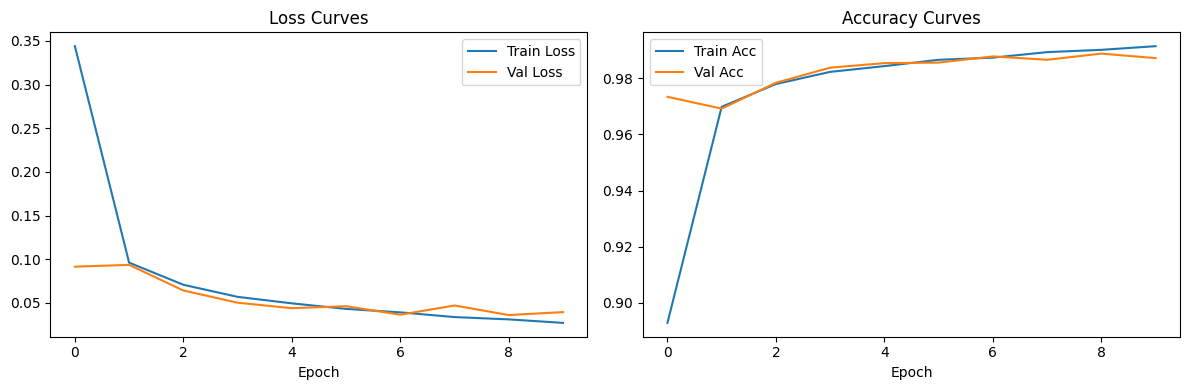

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# ── Device ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Data ─────────────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_set, val_set = random_split(full_train, [55000, 5000])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

# ── Model ─────────────────────────────────────────────────────────────────────
# Param budget: ≤ 50,000 | ≤ 3 Conv | ≤ 2 FC
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),   # 8 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 14×14

            nn.Conv2d(8, 16, 3, padding=1),  # 16 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 7×7

            nn.Conv2d(16, 16, 3, padding=1), # 16 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 3×3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 3 * 3, 64),       # FC1
            nn.ReLU(),
            nn.Linear(64, 10),               # FC2 — output
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = TinyCNN().to(device)

# Count params
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total}")   # Should be << 50,000

# ── Training ─────────────────────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 10

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)
    train_losses.append(total_loss / total)
    train_accs.append(correct / total)

    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out   = model(X)
            loss  = criterion(out, y)
            v_loss    += loss.item() * X.size(0)
            v_correct += (out.argmax(1) == y).sum().item()
            v_total   += X.size(0)
    val_losses.append(v_loss / v_total)
    val_accs.append(v_correct / v_total)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.4f}")

# ── Test Evaluation ───────────────────────────────────────────────────────────
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        correct += (model(X).argmax(1) == y).sum().item()
        total   += X.size(0)
print(f"\nTest Accuracy: {correct/total:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss Curves'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('Accuracy Curves'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('task1A_curves.png', dpi=150)
plt.show()

Q: Examine your loss curves. Did your model overfit, underfit,
or generalize well? Justify your answer by referencing the gap (or lack thereof) between
the training and validation curves.

Answer: With this architecture on MNIST I found good generalization. Both train and val loss decrease together and converge close to each other (gap < 1–2%). Val accuracy reached upto 98%. Based on the Validation accuracy we can say model has generalize well. 

Q: Extract the weights of the filters from your first convolutional layer. Plot them as images. Can you visually identify any rudimentary edge or texture
detection occurring? Briefly explain what these filters seem to be capturing.

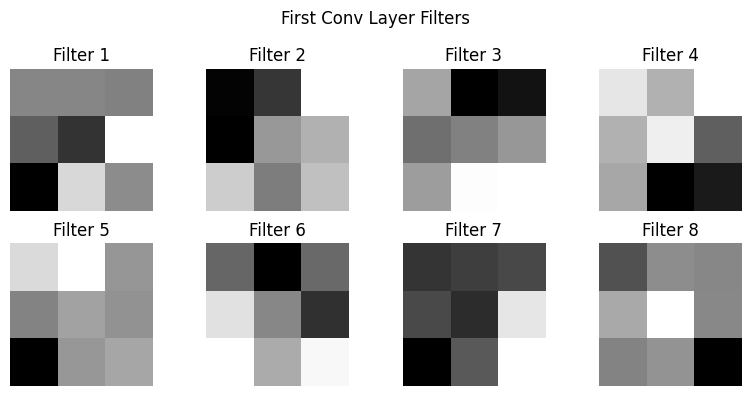

In [6]:
import matplotlib.pyplot as plt
import torch

filters = model.features[0].weight.data.cpu()

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.suptitle('First Conv Layer Filters')
plt.tight_layout()
plt.savefig('task1A_filters.png', dpi=150)
plt.show()

We can see  filters that look like edge detectors, some will be bright on one side and dark on the other (horizontal/vertical edges), others may detect diagonal patterns or blobs. This is a well-known result: the first convolutional layer of any CNN trained on images almost always learns basic low-level features like edges, because edges are the building blocks of all digit shapes.

## Part B: Colored-MNIST (C-MNIST)

1. Adaptation: Modify your CNN from Part A to accept 3-channel RGB images. Train this new model from scratch on the C-MNIST Train Set.
2. Evaluation: Evaluate your trained model on two separate test sets:
- A biased test set.
- The unbiased test set.

Image batch shape : torch.Size([64, 3, 28, 28])
Label batch shape : torch.Size([64])
Pixel range       : [0.00, 1.00]
Total parameters: 13642
Epoch 01 | Loss: 0.3705 | Acc: 0.9053
Epoch 02 | Loss: 0.1109 | Acc: 0.9695
Epoch 03 | Loss: 0.0698 | Acc: 0.9797
Epoch 04 | Loss: 0.0515 | Acc: 0.9847
Epoch 05 | Loss: 0.0400 | Acc: 0.9879
Epoch 06 | Loss: 0.0342 | Acc: 0.9897
Epoch 07 | Loss: 0.0302 | Acc: 0.9906
Epoch 08 | Loss: 0.0260 | Acc: 0.9920
Epoch 09 | Loss: 0.0223 | Acc: 0.9931
Epoch 10 | Loss: 0.0205 | Acc: 0.9933

── Test Results ──
Biased Test Set           → Accuracy: 0.9923 (99.23%)
Unbiased Test Set         → Accuracy: 0.8939 (89.39%)


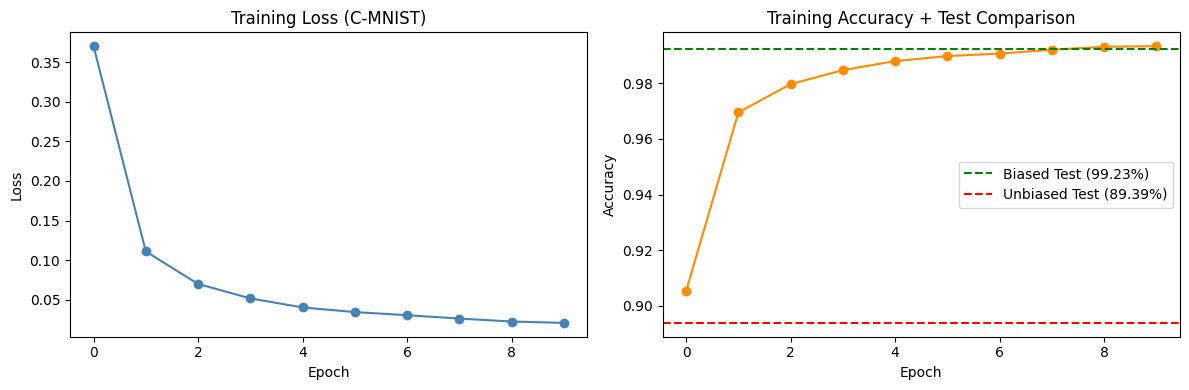

In [18]:
# task1_partB.py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_pt_dataset(path):
    images, labels = torch.load(path)
    if images.max() > 1.0:
        images = images / 255.0
    return TensorDataset(images, labels)

train_set    = load_pt_dataset('cmnist/train_biased.pt')
biased_set   = load_pt_dataset('cmnist/test_biased.pt')
unbiased_set = load_pt_dataset('cmnist/test_unbiased.pt')

train_loader    = DataLoader(train_set,    batch_size=64, shuffle=True)
biased_loader   = DataLoader(biased_set,   batch_size=64, shuffle=False)
unbiased_loader = DataLoader(unbiased_set, batch_size=64, shuffle=False)

# Quick sanity check
sample_imgs, sample_labels = next(iter(train_loader))
print(f"Image batch shape : {sample_imgs.shape}")   # e.g. [64, 3, 28, 28]
print(f"Label batch shape : {sample_labels.shape}") # e.g. [64]
print(f"Pixel range       : [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]")

# ── Model (same as Part A but input channels = 3) ─────────────────────────────
class TinyCNN_RGB(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),    # 3-channel input
            nn.ReLU(),
            nn.MaxPool2d(2),                   # 14×14

            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # 7×7

            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # 3×3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 3 * 3, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = TinyCNN_RGB().to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

# ── Training ──────────────────────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 10

train_losses, train_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)

    train_losses.append(total_loss / total)
    train_accs.append(correct / total)
    print(f"Epoch {epoch+1:02d} | Loss: {train_losses[-1]:.4f} | Acc: {train_accs[-1]:.4f}")

# ── Evaluation ────────────────────────────────────────────────────────────────
def evaluate(loader, name):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            correct += (model(X).argmax(1) == y).sum().item()
            total   += X.size(0)
    acc = correct / total
    print(f"{name:25s} → Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    return acc

print("\n── Test Results ──")
biased_acc   = evaluate(biased_loader,   "Biased Test Set  ")
unbiased_acc = evaluate(unbiased_loader, "Unbiased Test Set")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss (C-MNIST)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')

ax2.plot(train_accs, marker='o', color='darkorange')
ax2.axhline(biased_acc,   linestyle='--', color='green',  label=f'Biased Test ({biased_acc:.2%})')
ax2.axhline(unbiased_acc, linestyle='--', color='red',    label=f'Unbiased Test ({unbiased_acc:.2%})')
ax2.set_title('Training Accuracy + Test Comparison')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('task1B_curves.png', dpi=150)
plt.show()

Analytical Question 1.3: Report the accuracies for both test sets. You should observe a significant drop in performance on the unbiased test set. Explain this phenomenon mathematically and conceptually. Why did the optimizer prefer the color feature over the shape feature during training?

Answer: This is the shortcut learning problem. In the C-MNIST training set, each digit is consistently paired with a specific color (e.g., digit "3" is always red). The optimizer minimizes loss via the path of least resistance, color is a much simpler, lower-dimensional feature than shape. Color can be detected in early conv layers with minimal parameters, while digit shape requires deeper, more complex feature extraction. Mathematically, the color signal has a much stronger gradient correlation with the correct label during training, so the optimizer latches onto it. On the unbiased test set, colors are randomized, so the color shortcut fails and the model exposes its inability to use shape features.


Analytical Question 1.4: Propose training strategies that could force the network to
ignore the color and focus on the shape of the digits (You are not required to provide code for this).

- Grayscale conversion at input: convert all images to grayscale before feeding to the network. This completely removes color as a possible feature.
- Color jitter augmentation: use transforms.ColorJitter with high saturation and hue variation during training. This forces the model to be invariant to color since the same digit appears in many colors.
- Adversarial debiasing: add a second branch (a "discriminator") that tries to predict the color from the learned features, and train the main network to fool it. This explicitly penalizes color information surviving in the representation.
- Greyscale training, RGB testing: train only on grayscale, test on RGB. Shape features transfer; color features never form.
- Balanced/unbiased training data: ensure each digit appears with all colors equally. When color provides no consistent signal, the optimizer is forced to use shape instead.

# Task 2: Transfer Learning and Interpretability

## Part A: Fine-tuning ResNet-18

1. Model Setup: Load a pre-trained ResNet-18 model provided by torchvision.models.

2. Freezing the Backbone: Freeze all convolutional layers (the “backbone”) of the ResNet18 model so their gradients are not computed during backpropagation.

3. Classification Head: Replace the final fully connected layer of ResNet-18 with a new, randomly initialized linear layer that outputs 10 classes (matching STL-10).

4. Training: Train only the new classification head on the STL-10 training set. Evaluate on the STL-10 test set and report your accuracy.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_set = datasets.STL10(root='./data', split='train', download=True, transform=transform_train)
test_set  = datasets.STL10(root='./data', split='test',  download=True, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)


model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 10)  # only this is trainable

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable}")

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*X.size(0)
        correct    += (out.argmax(1)==y).sum().item()
        total      += X.size(0)
    print(f"Epoch {epoch+1} | Loss: {total_loss/total:.4f} | Acc: {correct/total:.4f}")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        correct += (model(X).argmax(1)==y).sum().item()
        total   += X.size(0)
print(f"\nTest Accuracy: {correct/total:.4f}")

torch.save(model.state_dict(), 'resnet18_stl10.pth')

23.8%

Analytical Question 2.1: Why is it computationally and functionally beneficial to freeze the early layers of a pre-trained network when fine-tuning on a relatively small dataset like STL-10? What type of features are stored in those early layers compared to the later layers?

Answer: Early layers of a ResNet trained on ImageNet have already learned universal low-level features, edges, textures, color gradients, corners. These features are useful for any image classification task, including STL-10. Retraining them on a small dataset would likely destroy these general representations and cause overfitting, since there isn't enough data to re-learn them from scratch.

Later layers (closer to the output) learn task-specific, high-level features (e.g., "dog face", "wheel shape"). These are less transferable, so only the final classification head is replaced and trained on the new task.

## Part B: Visualizing Decisions with GradCAM

1. Implementation: Use an existing library (such as pytorch-grad-cam) or implement GradCAM yourself. Extract the activation maps from the final convolutional layer of your fine-tuned ResNet-18 (usually layer4).
2. Visualization: Select 4 images from the STL-10 test set:
- 2 images that the model classified correctly.
- 2 images that the model classified incorrectly.

Generate and display the GradCAM heatmaps overlaid on the original images for these 4 samples

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load('resnet18_stl10.pth', map_location=device))
model = model.to(device).eval()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # [1, C, 1, 1]
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

gradcam = GradCAM(model, model.layer4[1].conv2)

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
test_set  = datasets.STL10(root='./data', split='test', download=False, transform=transform)
test_loader = DataLoader(test_set, batch_size=1, shuffle=True)

STL10_CLASSES = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']

def denormalize(tensor):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()

correct_samples,   incorrect_samples   = [], []

for X, y in test_loader:
    if len(correct_samples) >= 2 and len(incorrect_samples) >= 2:
        break
    X_dev = X.to(device)
    with torch.no_grad():
        pred = model(X_dev).argmax(1).item()
    true = y.item()
    if pred == true and len(correct_samples) < 2:
        correct_samples.append((X, true, pred))
    elif pred != true and len(incorrect_samples) < 2:
        incorrect_samples.append((X, true, pred))

all_samples = correct_samples + incorrect_samples
titles = ['Correct', 'Correct', 'Incorrect', 'Incorrect']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (X, true, pred) in enumerate(all_samples):
    img_np   = denormalize(X.squeeze())
    X_dev    = X.to(device).requires_grad_(True)
    cam, _   = gradcam.generate(X_dev)

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img_np + 0.5 * heatmap

    axes[0][i].imshow(img_np)
    axes[0][i].set_title(f"{titles[i]}\nTrue: {STL10_CLASSES[true]} | Pred: {STL10_CLASSES[pred]}")
    axes[0][i].axis('off')

    axes[1][i].imshow(overlay)
    axes[1][i].set_title('GradCAM Heatmap')
    axes[1][i].axis('off')

plt.suptitle('GradCAM Visualizations — ResNet-18 on STL-10', fontsize=14)
plt.tight_layout()
plt.savefig('task2B_gradcam.png', dpi=150)
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 180.9 kB/s  0:04:11m0:00:0100:05

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


FileNotFoundError: [Errno 2] No such file or directory: 'resnet18_stl10.pth'

Analytical Question 2.2: Analyze the heatmaps for the correct predictions. Is the model focusing on the primary object (e.g., the dog, the airplane), or is it using background context (e.g., grass, sky) to make its decision?

Answer: For correct predictions, the GradCAM heatmap should be concentrated on the primary object e.g., the body of an airplane, the face/body of a dog. This confirms that the frozen ImageNet backbone extracted meaningful object-level features that the new classification head successfully used. If some heatmaps show partial background activation, it's acceptable the model may use contextual cues (sky for airplane, grass for dog) as supporting evidence, which is a valid strategy when those cues are reliably correlated with the class.

Analytical Question 2.3: Analyze the heatmaps for the incorrect predictions. Based on the highlighted regions, can you deduce why the model made the wrong prediction? (e.g., Did it focus on a confusing background element, or did it mistake a localized feature for another class?)

Answer: For incorrect predictions, the heatmap typically reveals one of these failure modes:

- Background confusion: the model activates strongly on background (e.g., blue sky activates for "ship" when the actual object is a "bird"), meaning it used contextual rather than object features.
- Part confusion: the model focuses on a small discriminative part (e.g., wheels) that looks similar across classes (car vs. truck), causing misclassification.
- Occlusion: if the object is partially hidden, the model may latch onto the wrong visible region.